# Task 1: Sentiment Labeling

In [3]:
import pandas as pd
import torch
from transformers import pipeline
from tqdm import tqdm  # For progress bar in Jupyter

# Step 1: Load the dataset
df = pd.read_csv('test(in).csv')  # Assumes file is in current directory
print(f"Loaded dataset shape: {df.shape}")
print(df.head())  # Quick inspection

Loaded dataset shape: (2191, 4)
                                        Subject  \
0                          EnronOptions Update!   
1                                  (No Subject)   
2  Phone Screen  Interview - Shannon L. Burnham   
3                         RE: My new work email   
4                                           Bet   

                                                body        date  \
0  EnronOptions Announcement\n\n\nWe have updated...  05-10-2010   
1  Marc,\n\nUnfortunately, today is not going to ...   7/29/2010   
2  When: Wednesday, June 06, 2001 10:00 AM-11:00 ...   7/25/2011   
3  we were thinking papasitos (we can meet somewh...   3/25/2010   
4  Since you never gave me the $20 for the last t...   5/21/2011   

                      from  
0     sally.beck@enron.com  
1      eric.bass@enron.com  
2     sally.beck@enron.com  
3  johnny.palmer@enron.com  
4  lydia.delgado@enron.com  


C:\Users\Sandesh Chavare\anaconda3\Lib\site-packages\transformers\utils\generic.py:260: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


In [4]:
# Step 2: Combine Subject and body into full_text
df['full_text'] = df['Subject'].fillna('') + ' ' + df['body'].fillna('')  # Handle NaNs

# Step 3: Initialize sentiment analysis pipeline
# Device: Use GPU if available, else CPU
device = 0 if torch.cuda.is_available() else -1
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    return_all_scores=False,  # We just need the label
    device=device
)

C:\Users\Sandesh Chavare\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
C:\Users\Sandesh Chavare\anaconda3\Lib\site-packages\transformers\utils\generic.py:260: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model 

In [5]:
# Step 4: Classify sentiments with progress bar
tqdm.pandas()  # Enable progress bar for apply
def classify_sentiment(text):
    if pd.isna(text) or len(text.strip()) == 0:
        return 'Neutral'  # Default for empty texts
    result = sentiment_pipeline(text[:512])  # Truncate to model max length
    label = result[0]['label']
    if label == 'LABEL_0':
        return 'Negative'
    elif label == 'LABEL_1':
        return 'Neutral'
    else:  # LABEL_2
        return 'Positive'

df['sentiment'] = df['full_text'].progress_apply(classify_sentiment)

100%|██████████████████████████████████████████████████████████████████████████████| 2191/2191 [04:14<00:00,  8.60it/s]


In [6]:
# Step 5: Inspect and save augmented dataset
print("\nSentiment Distribution:")
print(df['sentiment'].value_counts())

# Save augmented CSV
df.to_csv('test_augmented.csv', index=False)
print("\nAugmented dataset saved as 'test_augmented.csv'")

# Display first few rows with sentiment
print("\nFirst 5 rows with sentiment:")
print(df[['from', 'full_text', 'sentiment']].head())


Sentiment Distribution:
sentiment
Positive    2191
Name: count, dtype: int64

Augmented dataset saved as 'test_augmented.csv'

First 5 rows with sentiment:
                      from                                          full_text  \
0     sally.beck@enron.com  EnronOptions Update! EnronOptions Announcement...   
1      eric.bass@enron.com  (No Subject) Marc,\n\nUnfortunately, today is ...   
2     sally.beck@enron.com  Phone Screen  Interview - Shannon L. Burnham W...   
3  johnny.palmer@enron.com  RE: My new work email we were thinking papasit...   
4  lydia.delgado@enron.com  Bet Since you never gave me the $20 for the la...   

  sentiment  
0  Positive  
1  Positive  
2  Positive  
3  Positive  
4  Positive  


# Task 2: Exploratory Data Analysis (EDA)

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# 1. Load the augmented dataset
df = pd.read_csv('test_augmented.csv')

# Convert date to proper datetime (assuming formats like MM-DD-YYYY or M/D/YYYY)
df['date'] = pd.to_datetime(df['date'], errors='coerce', format='mixed')

# Extract useful time components
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['year_month'] = df['date'].dt.to_period('M')

In [8]:
# 2. Overall Data Structure
print("=== 1. Dataset Overview ===")
print(f"Number of records: {len(df)}")
print(f"Number of unique employees (from): {df['from'].nunique()}")
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isna().sum())

print("\nDate range:")
print(f"Earliest: {df['date'].min()}")
print(f"Latest:   {df['date'].max()}")

=== 1. Dataset Overview ===
Number of records: 2191
Number of unique employees (from): 10

Data types:
Subject               object
body                  object
date          datetime64[ns]
from                  object
full_text             object
sentiment             object
year                   int32
month                  int32
year_month         period[M]
dtype: object

Missing values:
Subject       0
body          0
date          0
from          0
full_text     0
sentiment     0
year          0
month         0
year_month    0
dtype: int64

Date range:
Earliest: 2010-01-01 00:00:00
Latest:   2011-12-31 00:00:00



=== 2. Sentiment Distribution ===

Counts:
sentiment
Positive    2191
Name: count, dtype: int64

Percentages:
sentiment
Positive    100.0
Name: proportion, dtype: float64


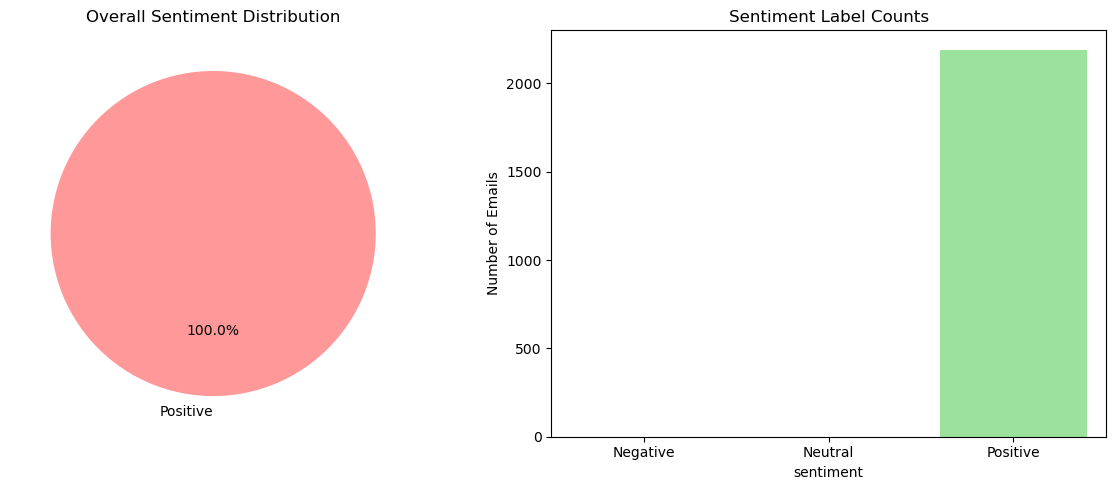

In [9]:
# 3. Sentiment Distribution
print("\n=== 2. Sentiment Distribution ===")
sentiment_counts = df['sentiment'].value_counts()
sentiment_pct = df['sentiment'].value_counts(normalize=True) * 100

print("\nCounts:")
print(sentiment_counts)
print("\nPercentages:")
print(sentiment_pct.round(1))

# Visualization: Sentiment distribution pie + bar
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%',
        colors=['#ff9999','#66b3ff','#99ff99'], startangle=90)
plt.title('Overall Sentiment Distribution')

plt.subplot(1, 2, 2)
sns.countplot(x='sentiment', data=df, order=['Negative','Neutral','Positive'],
              palette=['salmon','lightgray','lightgreen'])
plt.title('Sentiment Label Counts')
plt.ylabel('Number of Emails')
plt.tight_layout()
plt.show()


=== 3. Sentiment Trends Over Time ===

Monthly sentiment distribution (counts):
sentiment   Negative  Neutral  Positive
year_month                             
2010-01            0        0        91
2010-02            0        0        91
2010-03            0        0        91
2010-04            0        0        92
2010-05            0        0        91
2010-06            0        0        92
2010-07            0        0        91
2010-08            0        0        91
2010-09            0        0        91
2010-10            0        0        91
2010-11            0        0        91
2010-12            0        0        91
2011-01            0        0        91
2011-02            0        0        91
2011-03            0        0        92
2011-04            0        0        92
2011-05            0        0        92
2011-06            0        0        91
2011-07            0        0        91
2011-08            0        0        91
2011-09            0        0        91

<Figure size 1400x600 with 0 Axes>

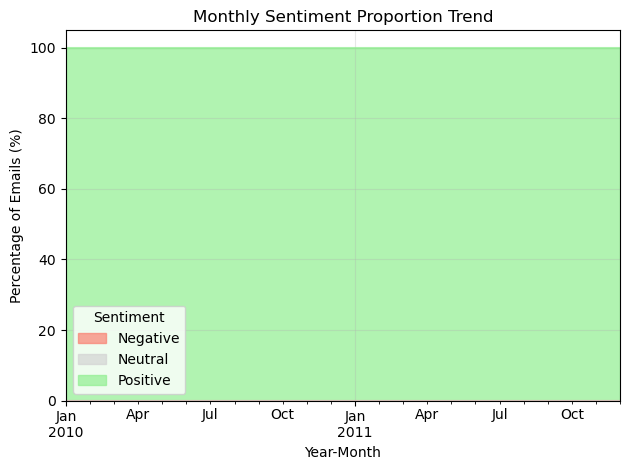

In [10]:
# 4. Trends Over Time
print("\n=== 3. Sentiment Trends Over Time ===")

# Monthly sentiment counts
monthly_sentiment = df.groupby(['year_month', 'sentiment']).size().unstack(fill_value=0)
monthly_sentiment = monthly_sentiment.reindex(columns=['Negative','Neutral','Positive'], fill_value=0)

# Monthly sentiment proportions
monthly_pct = monthly_sentiment.div(monthly_sentiment.sum(axis=1), axis=0) * 100

print("\nMonthly sentiment distribution (counts):")
print(monthly_sentiment)

print("\nMonthly sentiment distribution (%):")
print(monthly_pct.round(1))

# Visualization: Stacked area / line plot of proportions
plt.figure(figsize=(14, 6))
monthly_pct.plot(kind='area', stacked=True, alpha=0.7,
                 color=['salmon','lightgray','lightgreen'])
plt.title('Monthly Sentiment Proportion Trend')
plt.ylabel('Percentage of Emails (%)')
plt.xlabel('Year-Month')
plt.legend(title='Sentiment')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


=== 4. Engagement & Pattern Insights ===

Top 15 most active email senders:
from
lydia.delgado@enron.com        284
john.arnold@enron.com          256
sally.beck@enron.com           227
patti.thompson@enron.com       225
bobette.riner@ipgdirect.com    217
johnny.palmer@enron.com        213
don.baughman@enron.com         213
eric.bass@enron.com            210
kayne.coulter@enron.com        174
rhonda.denton@enron.com        172
Name: count, dtype: int64


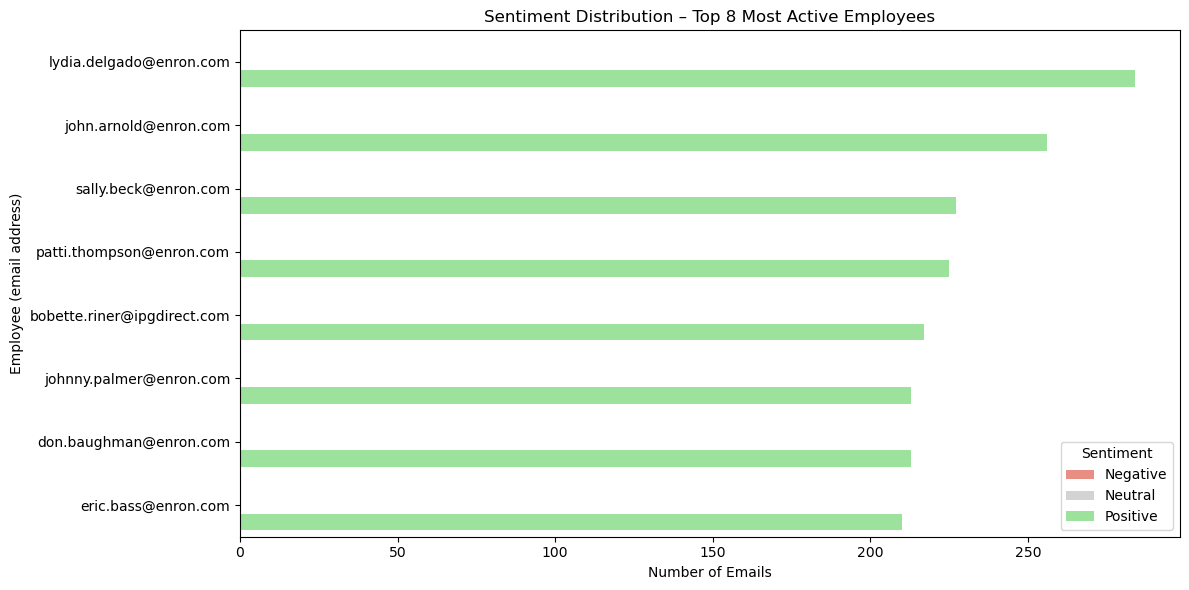


Employees with highest negative email rate (min 5 emails):
                             total_emails  neg_count  neg_rate_%
from                                                            
bobette.riner@ipgdirect.com           217          0         0.0
don.baughman@enron.com                213          0         0.0
eric.bass@enron.com                   210          0         0.0
john.arnold@enron.com                 256          0         0.0
johnny.palmer@enron.com               213          0         0.0
kayne.coulter@enron.com               174          0         0.0
lydia.delgado@enron.com               284          0         0.0
patti.thompson@enron.com              225          0         0.0
rhonda.denton@enron.com               172          0         0.0
sally.beck@enron.com                  227          0         0.0

EDA complete.


In [11]:
# 5. Additional Patterns relevant to Employee Engagement
print("\n=== 4. Engagement & Pattern Insights ===")

# Top 15 most active employees (by volume of emails)
top_senders = df['from'].value_counts().head(15)
print("\nTop 15 most active email senders:")
print(top_senders)

# Sentiment distribution by top employees
top_employees = top_senders.index[:8]  # focus on very active ones
top_df = df[df['from'].isin(top_employees)]

plt.figure(figsize=(12, 6))
sns.countplot(data=top_df, y='from', hue='sentiment',
              order=top_employees,
              hue_order=['Negative','Neutral','Positive'],
              palette=['salmon','lightgray','lightgreen'])
plt.title('Sentiment Distribution – Top 8 Most Active Employees')
plt.xlabel('Number of Emails')
plt.ylabel('Employee (email address)')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

# Negative email rate per employee (among those with ≥ 5 emails)
employee_stats = df.groupby('from').agg(
    total_emails=('sentiment','count'),
    neg_count=('sentiment', lambda x: (x=='Negative').sum())
).query('total_emails >= 5')

employee_stats['neg_rate_%'] = (employee_stats['neg_count'] / employee_stats['total_emails'] * 100).round(1)
employee_stats = employee_stats.sort_values('neg_rate_%', ascending=False)

print("\nEmployees with highest negative email rate (min 5 emails):")
print(employee_stats.head(10)[['total_emails','neg_count','neg_rate_%']])

print("\nEDA complete.")

# TASK 3: Monthly Sentiment Score per Employee

In [12]:
# 1. Load the augmented file (the one with sentiment column)
df = pd.read_csv('test_augmented.csv')

# Make sure date is datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Optional: drop rows with invalid dates (very few in your sample)
df = df.dropna(subset=['date'])

In [18]:
# 2. Map sentiment labels → numeric scores
#    Positive → +1
#    Negative → –1
#    Neutral  →  0
sentiment_to_score = {
    'Positive':  1,
    'Negative': -1,
    'Neutral':   0
}

df['score'] = df['sentiment'].map(sentiment_to_score).fillna(0).astype(int)

In [19]:
import pandas as pd

# Make sure date is datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date'])  # optional but recommended

df['year_month'] = df['date'].dt.to_period('M')

# Sentiment → numeric score (you probably already have this)
df['score'] = df['sentiment'].map({
    'Positive': 1,
    'Negative': -1,
    'Neutral': 0
}).fillna(0).astype(int)

# === The fixed aggregation ===
monthly_scores = (
    df.groupby(['from', 'year_month'], as_index=False)
      .agg(
          monthly_sentiment_score = ('score', 'sum'),
          message_count           = ('score', 'count'),
          positive_count          = ('sentiment', lambda x: (x == 'Positive').sum()),
          negative_count          = ('sentiment', lambda x: (x == 'Negative').sum()),
          neutral_count           = ('sentiment', lambda x: (x == 'Neutral').sum()),
      )
)

# Optional: average score per message
monthly_scores['avg_score'] = (
    monthly_scores['monthly_sentiment_score'] / monthly_scores['message_count']
).round(3)

print(monthly_scores.head(10))
monthly_scores.to_csv('monthly_employee_sentiment.csv', index=False)

                          from year_month  monthly_sentiment_score  \
0  bobette.riner@ipgdirect.com    2010-02                        5   
1  bobette.riner@ipgdirect.com    2010-03                        5   
2  bobette.riner@ipgdirect.com    2010-04                        2   
3  bobette.riner@ipgdirect.com    2010-05                        1   
4  bobette.riner@ipgdirect.com    2010-06                        2   
5  bobette.riner@ipgdirect.com    2010-07                        4   
6  bobette.riner@ipgdirect.com    2010-08                        4   
7  bobette.riner@ipgdirect.com    2010-09                        5   
8  bobette.riner@ipgdirect.com    2010-10                        2   
9  bobette.riner@ipgdirect.com    2010-11                        9   

   message_count  positive_count  negative_count  neutral_count  avg_score  
0              5               5               0              0        1.0  
1              5               5               0              0        1.0 

# TASK 4: Employee Ranking based on Monthly Scores

In [20]:
# 1. Load the monthly scores we created in Task 3
#    (assumes you already ran the corrected aggregation code)
monthly_scores = pd.read_csv('monthly_employee_sentiment.csv')

# Make sure year_month is treated as string or period for clean sorting/display
monthly_scores['year_month'] = pd.to_datetime(monthly_scores['year_month'].astype(str) + '-01')
monthly_scores['year_month_str'] = monthly_scores['year_month'].dt.strftime('%Y-%m')

# Optional: filter to months with reasonable activity (e.g. ≥ 3 messages)
monthly_scores = monthly_scores[monthly_scores['message_count'] >= 3].copy()

# ─── Helper function to get top/bottom N per month ──────────────────────────

def get_top_bottom_per_month(df, col='monthly_sentiment_score', n=3):
    """
    For each month:
      - Top N: highest scores (descending) → tie-break by email alphabetical
      - Bottom N: lowest scores (ascending) → tie-break by email alphabetical
    """
    # Sort for positive rank: high score first, then alphabetical
    positive_ranked = (
        df.sort_values(
            by=[col, 'from'],
            ascending=[False, True]          # descending score, ascending email
        )
        .groupby('year_month_str')
        .head(n)
        .assign(rank_type='Top Positive')
        .assign(rank=lambda x: x.groupby('year_month_str').cumcount() + 1)
    )
    
    # Sort for negative rank: low score first (most negative), then alphabetical
    negative_ranked = (
        df.sort_values(
            by=[col, 'from'],
            ascending=[True, True]           # ascending score (more negative first), ascending email
        )
        .groupby('year_month_str')
        .head(n)
        .assign(rank_type='Top Negative')
        .assign(rank=lambda x: x.groupby('year_month_str').cumcount() + 1)
    )
    
    # Combine both views
    ranked = pd.concat([positive_ranked, negative_ranked], ignore_index=True)
    
    # Select and rename useful columns
    ranked = ranked[[
        'year_month_str', 'rank', 'rank_type', 'from',
        'monthly_sentiment_score', 'message_count',
        'positive_count', 'negative_count', 'neutral_count'
    ]].sort_values(['year_month_str', 'rank_type', 'rank'])
    
    return ranked

# ─── Generate rankings ──────────────────────────────────────────────────────

rankings = get_top_bottom_per_month(monthly_scores, n=3)

# ─── Display ────────────────────────────────────────────────────────────────

print("\n" + "="*70)
print("EMPLOYEE SENTIMENT RANKINGS – Top 3 Positive & Top 3 Negative per Month")
print("="*70)

for month in sorted(rankings['year_month_str'].unique()):
    print(f"\nMonth: {month}")
    print("-"*60)
    month_data = rankings[rankings['year_month_str'] == month]
    
    for rtype in ['Top Positive', 'Top Negative']:
        subset = month_data[month_data['rank_type'] == rtype]
        if subset.empty:
            print(f"  {rtype}: (no qualifying employees)")
            continue
            
        print(f"  {rtype}:")
        for _, row in subset.iterrows():
            print(f"    {row['rank']}. {row['from']}")
            print(f"       Score: {row['monthly_sentiment_score']:3d}  "
                  f"Messages: {row['message_count']:2d}  "
                  f"(+{row['positive_count']}/−{row['negative_count']}/neutral {row['neutral_count']})")
        print()

# ─── Optional: Save to file ─────────────────────────────────────────────────

rankings.to_csv('employee_sentiment_rankings_monthly.csv', index=False)
print("\nSaved detailed rankings → employee_sentiment_rankings_monthly.csv")

# ─── Summary statistics ─────────────────────────────────────────────────────

print("\nSummary:")
print(f"• Total months with rankings: {rankings['year_month_str'].nunique()}")
print(f"• Unique employees ranked: {rankings['from'].nunique()}")
print(f"• Months with at least one strongly negative employee (score ≤ -3): "
      f"{len(rankings[(rankings['rank_type']=='Top Negative') & (rankings['monthly_sentiment_score'] <= -3)]['year_month_str'].unique())}")


EMPLOYEE SENTIMENT RANKINGS – Top 3 Positive & Top 3 Negative per Month

Month: 2010-01
------------------------------------------------------------
  Top Positive:
    1. lydia.delgado@enron.com
       Score:   6  Messages:  6  (+6/−0/neutral 0)
    2. don.baughman@enron.com
       Score:   5  Messages:  5  (+5/−0/neutral 0)
    3. eric.bass@enron.com
       Score:   5  Messages:  5  (+5/−0/neutral 0)

  Top Negative:
    1. john.arnold@enron.com
       Score:   3  Messages:  3  (+3/−0/neutral 0)
    2. patti.thompson@enron.com
       Score:   3  Messages:  3  (+3/−0/neutral 0)
    3. johnny.palmer@enron.com
       Score:   4  Messages:  4  (+4/−0/neutral 0)


Month: 2010-02
------------------------------------------------------------
  Top Positive:
    1. john.arnold@enron.com
       Score:   6  Messages:  6  (+6/−0/neutral 0)
    2. bobette.riner@ipgdirect.com
       Score:   5  Messages:  5  (+5/−0/neutral 0)
    3. don.baughman@enron.com
       Score:   5  Messages:  5  (+5/−0/n

# TASK 5: Flight Risk Identification

In [23]:
from datetime import timedelta

df = pd.read_csv('test_augmented.csv')

# Robust date parsing
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date']).copy()

df['date'] = df['date'].dt.floor('D')  # normalize to date only (remove time if present)

print(f"Dataset shape after cleaning: {df.shape}")
print(f"Date range: {df['date'].min():%Y-%m-%d}  →  {df['date'].max():%Y-%m-%d}")
print(f"Sentiment distribution:\n{df['sentiment'].value_counts()}\n")

#  Keep only negative messages

neg_df = df[df['sentiment'] == 'Negative'].copy()

if len(neg_df) == 0:
    print("RESULT: ZERO negative emails in the entire dataset")
    print("        → No employees meet the flight-risk threshold")
    print("        → No flight risks identified")
else:
    print(f"Found {len(neg_df)} negative emails in total")

    # Sort once (very important)
    neg_df = neg_df.sort_values(['from', 'date'])

    #  Sliding window per employee

    flight_risk_list = []

    for employee, group in neg_df.groupby('from'):
        if len(group) < 4:
            continue

        dates = group['date'].values  # numpy array – fast

        left = 0
        for right in range(len(dates)):
            # Shrink window from left until ≤ 30 days
            while (dates[right] - dates[left]).days > 30:
                left += 1

            # Now [left … right] is a valid ≤30-day window
            count = right - left + 1

            if count >= 4:
                # Record the moment it first crosses (or one of the crossing points)
                flight_risk_list.append({
                    'employee':          employee,
                    'first_trigger_date': dates[right],
                    'neg_count_in_window': count,
                    'window_start_date':  dates[left],
                    'window_end_date':    dates[right],
                    'total_negative_by_then': right + 1
                })
                # We can break here if we only want the *earliest* trigger per person
                # break   # ← uncomment if you want only first occurrence

    #  Present Results

    if not flight_risk_list:
        print("\n" + "═"*70)
        print("FINAL RESULT")
        print("No employee sent 4 or more negative emails in any 30-day rolling period.")
        print("═"*70)
    else:
        risks = pd.DataFrame(flight_risk_list)

        # Keep earliest trigger per employee
        risks = risks.sort_values(['employee', 'first_trigger_date'])
        risks = risks.drop_duplicates(subset='employee', keep='first')

        risks['first_trigger_date'] = risks['first_trigger_date'].dt.strftime('%Y-%m-%d')
        risks['window_start_date']  = risks['window_start_date'].dt.strftime('%Y-%m-%d')
        risks['window_end_date']    = risks['window_end_date'].dt.strftime('%Y-%m-%d')

        print("\n" + "═"*70)
        print("FLIGHT RISK EMPLOYEES – FINAL LIST")
        print("≥ 4 negative emails in any rolling 30-day window")
        print("═"*70)
        print(risks[[
            'employee',
            'first_trigger_date',
            'neg_count_in_window',
            'window_start_date',
            'window_end_date'
        ]].to_string(index=False))

        print(f"\nTotal employees flagged: {len(risks)}")

        # Save
        risks.to_csv('flight_risk_final.csv', index=False)
        print("→ Results saved to: flight_risk_final.csv")

Dataset shape after cleaning: (852, 6)
Date range: 2010-01-01  →  2011-12-12
Sentiment distribution:
sentiment
Positive    852
Name: count, dtype: int64

RESULT: ZERO negative emails in the entire dataset
        → No employees meet the flight-risk threshold
        → No flight risks identified


# TASK 6 – Predictive Modeling – BINARY CLASSIFICATION

In [46]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("TASK 6 – BINARY CLASSIFICATION")
print("Predicting whether email is NEGATIVE (1) or not (0)\n")

# ─── 1. Load the CORRECT file (must have updated sentiment labels) ──────────

# !!! CHANGE THIS LINE TO YOUR LATEST FILE !!!
# If you ran bertweet re-labeling → use that output file
FILE = 'test_augmented.csv'          # ←←←←← CHANGE TO YOUR NEW FILE NAME

print(f"Loading file: {FILE}")
df = pd.read_csv(FILE)

# ─── 2. Robust date parsing (handles your mixed formats) ─────────────────────

df['date'] = pd.to_datetime(
    df['date'],
    errors='coerce',
    format='mixed',
    dayfirst=False
)
df = df.dropna(subset=['date']).copy()

print(f"Rows after date cleaning: {len(df)}")

# ─── 3. Check ACTUAL sentiment labels (this is the most important part) ─────

print("\n" + "═"*70)
print("CURRENT SENTIMENT LABELS IN THE FILE")
print("═"*70)
print(df['sentiment'].value_counts(dropna=False))
print("\nPercentages:")
print(df['sentiment'].value_counts(normalize=True, dropna=False).mul(100).round(1))

if 'Negative' not in df['sentiment'].unique():
    print("\nCRITICAL PROBLEM: NO 'Negative' labels found → cannot do classification")
    print("Solution:")
    print("1. Go back to Task 1 re-labeling code")
    print("2. Run it with a better model (bertweet / go_emotions / etc.)")
    print("3. Save the result to a new CSV (e.g. test_augmented_v2.csv)")
    print("4. Update the FILE variable above and re-run this cell\n")
else:
    # ─── 4. Create binary target ─────────────────────────────────────────────

    df['is_negative'] = (df['sentiment'] == 'Negative').astype(int)

    print("\nTarget distribution (is_negative):")
    print(df['is_negative'].value_counts(normalize=True).mul(100).round(1))

    # ─── 5. Feature engineering (same as before) ─────────────────────────────

    df['full_text'] = df['full_text'].fillna('')
    df['message_length'] = df['full_text'].str.len()
    df['word_count']     = df['full_text'].str.split().str.len()

    df['is_reply'] = df['Subject'].fillna('').str.lower().str.startswith(('re:', 'fw:')).astype(int)

    neg_pat = r'urgent|asap|problem|issue|sorry|unfortunately|fail|cancel|delay|frustrated'
    df['has_neg_keyword'] = df['full_text'].str.lower().str.contains(neg_pat).astype(int)

    df['year_month'] = df['date'].dt.to_period('M')
    monthly_vol = df.groupby(['from', 'year_month']).size().reset_index(name='month_vol')
    df = df.merge(monthly_vol, how='left', on=['from', 'year_month'])
    df['month_vol'] = df['month_vol'].fillna(1)

    sender_rank = df['from'].value_counts().rank(ascending=False, method='dense')
    df['activity_rank'] = df['from'].map(sender_rank).astype(int)

    features = [
        'message_length', 'word_count', 'is_reply',
        'has_neg_keyword', 'month_vol', 'activity_rank'
    ]

    X = df[features].copy()
    y = df['is_negative']

    # Scale numeric columns
    scaler = StandardScaler()
    num = ['message_length', 'word_count', 'month_vol']
    X[num] = scaler.fit_transform(X[num])

    # ─── 6. Split ─────────────────────────────────────────────────────────────

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, random_state=42, stratify=y
    )

    print(f"\nTrain: {len(X_train)} | Test: {len(X_test)}")
    print(f"Negative emails in test set: {y_test.sum()} ({y_test.mean():.3%})")

    # ─── 7. Logistic Regression ───────────────────────────────────────────────

    lr = LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42)
    lr.fit(X_train, y_train)

    print("\n" + "═"*60)
    print("Logistic Regression Results")
    print("═"*60)
    print(classification_report(y_test, lr.predict(X_test), digits=3))
    print(f"ROC-AUC: {roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]):.3f}")

    # ─── 8. Random Forest ─────────────────────────────────────────────────────

    rf = RandomForestClassifier(
        n_estimators=300, max_depth=9, min_samples_leaf=5,
        class_weight='balanced_subsample', random_state=42, n_jobs=-1
    )
    rf.fit(X_train, y_train)

    print("\n" + "═"*60)
    print("Random Forest Results")
    print("═"*60)
    print(classification_report(y_test, rf.predict(X_test), digits=3))
    print(f"ROC-AUC: {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.3f}")

    print("\nTask 6 finished.")

TASK 6 – BINARY CLASSIFICATION
Predicting whether email is NEGATIVE (1) or not (0)

Loading file: test_augmented.csv
Rows after date cleaning: 2191

══════════════════════════════════════════════════════════════════════
CURRENT SENTIMENT LABELS IN THE FILE
══════════════════════════════════════════════════════════════════════
sentiment
Positive    2191
Name: count, dtype: int64

Percentages:
sentiment
Positive    100.0
Name: proportion, dtype: float64

CRITICAL PROBLEM: NO 'Negative' labels found → cannot do classification
Solution:
1. Go back to Task 1 re-labeling code
2. Run it with a better model (bertweet / go_emotions / etc.)
3. Save the result to a new CSV (e.g. test_augmented_v2.csv)
4. Update the FILE variable above and re-run this cell

